In [ ]:
# NOTE: ADD YOUR GITHUB ACCESS TOKEN TO COLAB SECRETS FOR THIS CELL TO RUN

# imports
import numpy as np
import pandas as pd
import matplotlib as plt
import math
import os
import re
import sklearn
!pip install lime -q
import lime
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

In [ ]:
from torch.utils.data import DataLoader, Dataset
!pip install torchmetrics
import torchmetrics
import torchvision

In [ ]:
# reading in the New York City dataframe
NYC = pd.read_csv(r'C:\Users\khatch\Documents\GitHub\Intersection_Safety_Prediction\Data\FARS + Supplements (2015-2018)\Updated_NYC_CRASHES_2015-2018.csv')

In [ ]:
# a function used to get street view pathways for each city given the provided dataframe
# which contains heading, longitude, and latitude
#streetViewToken = userdata.get('StreetViewProject')

def getStreetViews(approach_df):
  approach_df_new = approach_df.copy()

  for index, row in approach_df_new.iterrows():
    string_no_sig = ("https://maps.googleapis.com/maps/api/streetview?size=400x400&location=" + str(row['cam_lat']) + ","
                     + str(row['cam_lon']) + "&heading=" + str(row['cam_heading'])) #+ "&key=" + streetViewToken)

    full_string = sign_url(string_no_sig)
    approach_df_new.loc[index, 'path'] = full_string
  return approach_df_new

In [ ]:
# Used to decode street view api signatures. Taken entirely from Google API dev
# guide (https://developers.google.com/maps/documentation/streetview/digital-signature#generate-signed-request)

#!/usr/bin/python
# -*- coding: utf-8 -*-
""" Signs a URL using a URL signing secret """

import hashlib
import hmac
import base64
import urllib.parse as urlparse


def sign_url(input_url=None, secret="wc-C8Kljh7dvUwlQZDLXu1yLS50="):
    """ Sign a request URL with a URL signing secret.
      Usage:
      from urlsigner import sign_url
      signed_url = sign_url(input_url=my_url, secret=SECRET)
      Args:
      input_url - The URL to sign
      secret    - Your URL signing secret
      Returns:
      The signed request URL
  """

    if not input_url or not secret:
        raise Exception("Both input_url and secret are required")

    url = urlparse.urlparse(input_url)

    # We only need to sign the path+query part of the string
    url_to_sign = url.path + "?" + url.query

    # Decode the private key into its binary format
    # We need to decode the URL-encoded private key
    decoded_key = base64.urlsafe_b64decode(secret)

    # Create a signature using the private key and the URL-encoded
    # string using HMAC SHA1. This signature will be binary.
    signature = hmac.new(decoded_key, str.encode(url_to_sign), hashlib.sha1)

    # Encode the binary signature into base64 for use within a URL
    encoded_signature = base64.urlsafe_b64encode(signature.digest())

    original_url = url.scheme + "://" + url.netloc + url.path + "?" + url.query

    # Return signed URL
    return original_url + "&signature=" + encoded_signature.decode()

In [ ]:
# getting the static street view API paths
NYC_with_path = getStreetViews(NYC)

In [ ]:
# creates a CSV file with the paths
YC_with_path.to_csv("NYC_with_path.csv", index=False)

In [ ]:
# reading in the CSV file to avoid having to create paths every time
url1 = "/content/NYC_with_path.csv"
NYC_with_path = pd.read_csv(url1)

In [ ]:
# creates the index columns
NYC_with_path['index'] = 0

In [ ]:
# creates indexes for rows
for i, _ in NYC_with_path.iterrows():
  NYC_with_path.at[i, 'index'] = i

In [ ]:
# Helper for max_mixed
def extract_ints_from_string(str):
    return [int(x) for x in re.findall(r'\d+', str)]

In [ ]:
# Helper for num_lanes in group_intersections
def max_mixed(x):
    def extract(v):
        if isinstance(v, str):
            return max(extract_ints_from_string(v))
        elif math.isnan(v):
            return 0
        return int(v)  # also convert scalar values just in case
    return max(extract(v) for v in x)

In [ ]:
# Combine each intersection into one data point
def group_intersections(df):
    df_grouped = df.groupby('intersection_id', as_index = False).agg({
        'int_lat': 'first',
        'int_lon': 'first',
        'cam_lat': 'first',
        'cam_lon': 'first',
        'cam_heading': 'first',
        'speed_limit': 'max',
        'road_type': 'first',
        'is_major_road': 'max',
        'has_crosswalk': 'any',
        'has_camera': 'any',
        'has_speed_display': 'any',
        'has_traffic_light': 'any',
        'has_stop_sign': 'any',
        'number_of_connecting_roads': 'max',
        'is_lit': 'first',
        'has_bike_lane': 'first',
        'num_lanes': max_mixed,
        'number_of_accidents': 'first',
        'has_had_fatal': 'any',
        'path': 'first',
        'index': 'first'
    })
    return df_grouped

In [ ]:
# groups the intersections of NYC_with_path
NYC_with_path_grouped = group_intersections(NYC_with_path)

In [ ]:
NYC_with_path_grouped.head()

,intersection_id,int_lat,int_lon,cam_lat,cam_lon,cam_heading,speed_limit,road_type,is_major_road,has_crosswalk,...,has_traffic_light,has_stop_sign,number_of_connecting_roads,is_lit,has_bike_lane,num_lanes,number_of_accidents,has_had_fatal,path,index
0,0,40.786345,-73.794748,40.786400,-73.794586,245.422095,65.0,motorway,1,False,...,False,False,3,NaN,NaN,4,37,False,https://maps.googleapis.com/maps/api/streetvie...,0
1,1,40.789376,-73.785963,40.789358,-73.786140,81.793997,65.0,motorway,1,False,...,False,False,3,NaN,NaN,3,15,False,https://maps.googleapis.com/maps/api/streetvie...,3
2,2,40.787164,-73.791923,40.787279,-73.792017,147.115602,25.0,motorway_link,0,False,...,True,False,3,NaN,NaN,1,0,False,https://maps.googleapis.com/maps/api/streetvie...,6
3,3,40.762429,-73.757091,40.762551,-73.757169,153.105318,65.0,motorway_link,1,False,...,False,False,3,NaN,NaN,3,195,False,https://maps.googleapis.com/maps/api/streetvie...,9
4,4,40.762405,-73.756566,40.762503,-73.756443,222.809855,65.0,motorway_link,1,False,...,False,False,3,NaN,NaN,3,0,False,https://maps.googleapis.com/maps/api/streetvie...,12


In [ ]:
# an example API call (does not work anymore since the API key is deactivated)
NYC_with_path['path'][3]

'https://maps.googleapis.com/maps/api/streetview?size=400x400&location=40.78935846815435,-73.78613958234634&heading=81.7939970573932&signature=yEcr_K4UwiBDXzRnHyAnp9A6EFA='

In [ ]:
# shuffles the dataframe
shuffled_NYC = NYC_with_path_grouped.sample(frac=1, random_state=41)
full_data = shuffled_NYC[0:9990]
full_data

,intersection_id,int_lat,int_lon,cam_lat,cam_lon,cam_heading,speed_limit,road_type,is_major_road,has_crosswalk,...,has_traffic_light,has_stop_sign,number_of_connecting_roads,is_lit,has_bike_lane,num_lanes,number_of_accidents,has_had_fatal,path,index
31290,32162,40.774007,-73.792250,40.773936,-73.792401,57.617241,25.0,tertiary,0,False,...,False,False,3,NaN,NaN,0,0,False,https://maps.googleapis.com/maps/api/streetvie...,114113
19009,19484,40.694978,-73.808351,40.694928,-73.808516,67.531914,25.0,residential,0,False,...,True,False,4,NaN,NaN,0,10,False,https://maps.googleapis.com/maps/api/streetvie...,70444
14352,14629,40.812604,-73.923273,40.812473,-73.923316,13.371577,25.0,residential,0,False,...,False,False,3,NaN,NaN,2,10,False,https://maps.googleapis.com/maps/api/streetvie...,53832
39392,41277,40.640535,-74.171288,40.640400,-74.171285,358.406410,25.0,residential,0,False,...,False,False,3,NaN,NaN,2,4,False,https://maps.googleapis.com/maps/api/streetvie...,141229
35634,36878,40.616669,-74.137377,40.616537,-74.137414,11.592208,25.0,residential,0,False,...,False,False,3,NaN,NaN,0,0,False,https://maps.googleapis.com/maps/api/streetvie...,128845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9043,9164,40.585172,-73.944931,40.585193,-73.944756,260.491765,65.0,secondary,1,False,...,False,False,3,NaN,NaN,2,3,False,https://maps.googleapis.com/maps/api/streetvie...,34313
19061,19537,40.667734,-73.735200,40.667610,-73.735271,22.773765,25.0,residential,0,False,...,False,False,4,NaN,NaN,0,8,False,https://maps.googleapis.com/maps/api/streetvie...,70627
1320,1332,40.716928,-74.009108,40.717002,-74.009256,122.664035,65.0,residential,1,False,...,True,False,4,NaN,NaN,1,0,False,https://maps.googleapis.com/maps/api/streetvie...,5009
32385,33298,40.703877,-73.912555,40.703960,-73.912696,127.125203,65.0,secondary,1,False,...,True,False,4,NaN,NaN,2,11,False,https://maps.googleapis.com/maps/api/streetvie...,117923


In [ ]:
# the image path name
full_data.loc[:, 'image_local_path'] = (
    r"C:\Users\khatch\Documents\GitHub\Intersection_Safety_Prediction\Data\training_images_10k\training_data_10k\img_"
    + full_data['index'].astype(str).str.zfill(6)
    + ".jpg"
)

C:\Users\khatch\AppData\Local\Temp\ipykernel_16656\811760679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [ ]:
# used for train/test splitting later on
from sklearn.model_selection import train_test_split
train, test = train_test_split(full_data, test_size=0.2, random_state=41)

In [ ]:
# used to download and save the images to avoid multiple API calls
import requests
import os
import time

def download_images(df, out_dir, sleep=0.1):
  os.makedirs(out_dir, exist_ok=True)
  local_paths = []

  for i, row in df.iterrows():
    url = row["path"]
    filename = f"img_{row['index']:06d}.jpg"
    filepath = os.path.join(out_dir, filename)

    if not os.path.exists(filepath):
      r = requests.get(url, timeout=10)
      if r.status_code == 200:
        with open(filepath, "wb") as f:
          f.write(r.content)
      else:
        print(f"Failed: {url}")
        print(f"Status: {r.status_code}")
        continue

      time.sleep(sleep)

    local_paths.append(filepath)

  return local_paths

In [ ]:
# downloading the training and testing images

#train["path"] = download_images(train, "data/images/train")
image_paths_train = train["image_local_path"].values
image_labels_train = train["number_of_accidents"]
index_df_train = train["index"]

#test["local_path"] = download_images(test,  "data/images/test")
image_paths_test = test["image_local_path"].values
image_labels_test = test["number_of_accidents"]
index_df_test = test["index"]

# defines the image size in pixels
size = (400, 400)

In [ ]:
# setting up the images (wit labels and indices) to be contained in the train and test dataloaders
class ImageDataset(Dataset):
    def __init__(self, index_df, labels, transform = None, target_transform = None):
        self.index_df = index_df
        self.num_acc = labels
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.num_acc)

    def __getitem__(self, idx):
        image_path = r"C:\Users\khatch\Documents\GitHub\Intersection_Safety_Prediction\Data\training_images_10k\training_data_10k\img_" + str(self.index_df.iloc[idx]).zfill(6) + ".jpg"
        image = torchvision.io.decode_image(image_path).float()
        num_acc = self.num_acc.iloc[idx].astype(np.float32)
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            num_acc = self.target_transform(num_acc)
        return image, num_acc

In [ ]:
# creating the dataloaders
train_dataset = ImageDataset(index_df_train, image_labels_train)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = ImageDataset(index_df_test, image_labels_test)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [ ]:
# creating the CNN model
class CNNet(nn.Module):
    def __init__(self):
        super(CNNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 35, padding=15, stride=5) # takes 3-channel images
        self.pool1 = nn.MaxPool2d(2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, 4, stride=2)
        self.pool2 = nn.MaxPool2d(2, stride=2)

        #self.conv3 = nn.Conv2d(64, 128, 4, stride=4)

        self.fc1 = nn.Linear(9*9*64, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        #x = F.relu(self.conv3(x))
        #print("After last conv")
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

cnn = CNNet()
print(cnn)

CNNet(
  (conv1): Conv2d(3, 32, kernel_size=(35, 35), stride=(5, 5), padding=(15, 15))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=5184, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
# setting the loss and optimizer
criterion = nn.HuberLoss()
optimizer = optim.Adam(cnn.parameters())

In [ ]:
# training the model
for epoch in range(5):
    cnn.train()
    running_loss = 0.0
    loss_list = []
    i_list = []
    for i, data in enumerate(train_dataloader, 0):

        inputs, labels = data
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        outputs = cnn(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loss_list.append(float(f'{(running_loss) / 2000:.3f}'))
        i_list.append(int(i))
        if i % 10 == 9:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,    10] loss: 0.420
[1,    20] loss: 0.064
[1,    30] loss: 0.049
[1,    40] loss: 0.069
[1,    50] loss: 0.063
[1,    60] loss: 0.067
[1,    70] loss: 0.065
[1,    80] loss: 0.049
[1,    90] loss: 0.075
[1,   100] loss: 0.050
[1,   110] loss: 0.057
[1,   120] loss: 0.063
[1,   130] loss: 0.063
[1,   140] loss: 0.063
[1,   150] loss: 0.064
[1,   160] loss: 0.060
[1,   170] loss: 0.073
[1,   180] loss: 0.050
[1,   190] loss: 0.064
[1,   200] loss: 0.071
[1,   210] loss: 0.064
[1,   220] loss: 0.053
[1,   230] loss: 0.061
[1,   240] loss: 0.045
[1,   250] loss: 0.059
[1,   260] loss: 0.059
[1,   270] loss: 0.070
[1,   280] loss: 0.048
[1,   290] loss: 0.070
[1,   300] loss: 0.055
[1,   310] loss: 0.077
[1,   320] loss: 0.059
[1,   330] loss: 0.060
[1,   340] loss: 0.067
[1,   350] loss: 0.053
[1,   360] loss: 0.057
[1,   370] loss: 0.054
[1,   380] loss: 0.051
[1,   390] loss: 0.058
[1,   400] loss: 0.072
[1,   410] loss: 0.070
[1,   420] loss: 0.061
[1,   430] loss: 0.056
[1,   440] 

In [ ]:
# plotting the loss values over training time
def plot_fit_history(i, loss):
  from plotnine import ggplot, aes, geom_line, facet_wrap, theme_bw, theme, scale_x_continuous, element_blank, labs

  # A function that plots model accuracy and loss during training
  df = pd.DataFrame({'I': i, 'Loss': loss})


  return (ggplot(df, mapping=aes(x="I", y="Loss"))+
   geom_line()+
   scale_x_continuous(breaks=np.arange(0, len(df)))+
   labs(x = "I", y="Loss")+
   theme_bw()+
   theme(panel_grid=element_blank()))

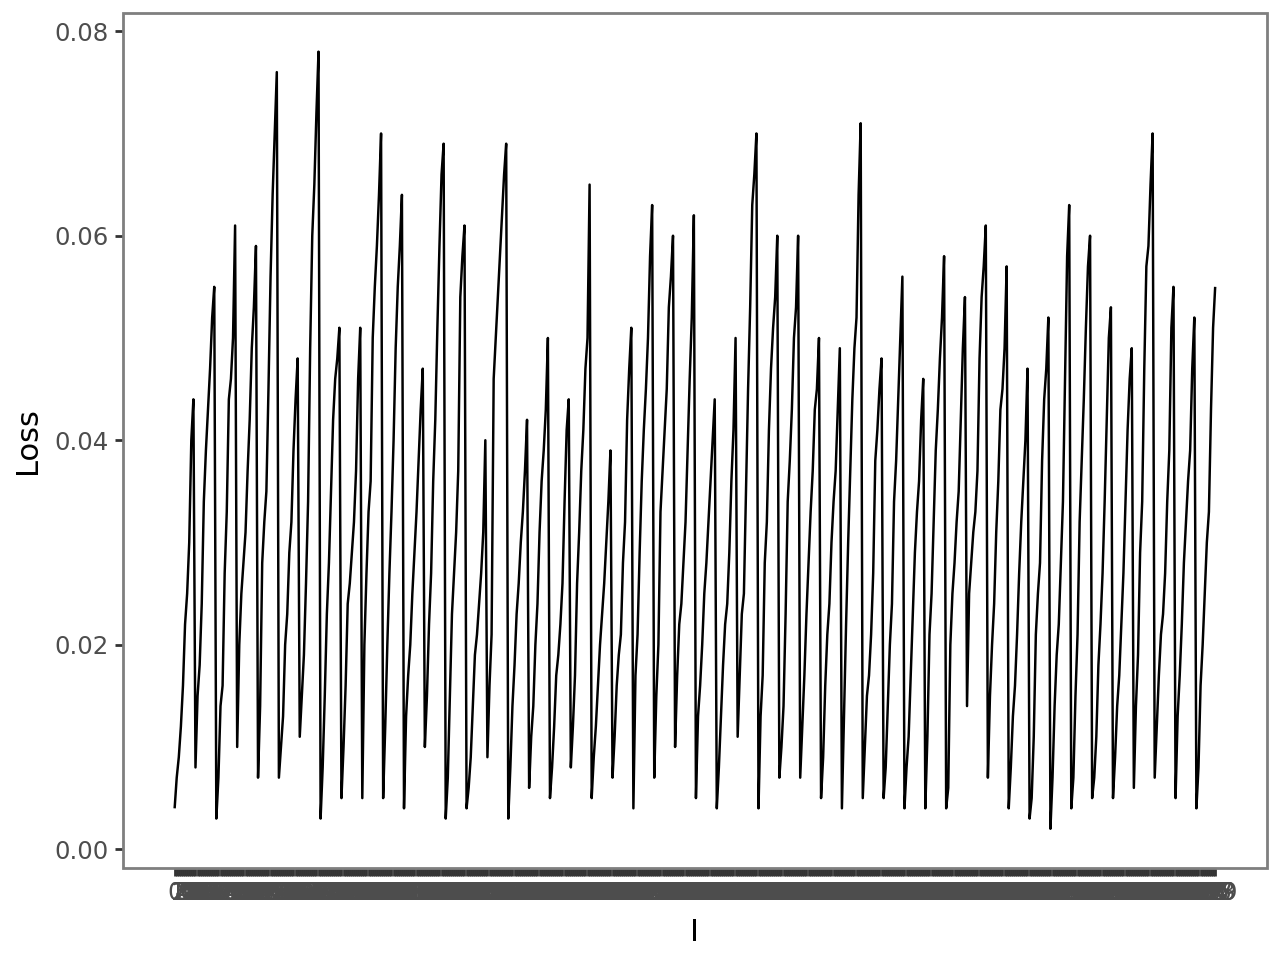

In [ ]:
plot_fit_history(i_list, loss_list)

In [ ]:
# saving the model
PATH = './cifar_cnn.pth'
torch.save(cnn.state_dict(), PATH)

In [ ]:
# Load saved model from github
cnn = CNNet()
cnn.load_state_dict(torch.load("/content/Intersection_Safety_Prediction/intersection_cnn.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
# setting up mean squared error as a metric
mse_metric = torchmetrics.MeanSquaredError()

In [ ]:
# evaluating the model on the test data
cnn.eval()
# testing model accuracy using the test data
total = 0
mse = 0.0

with torch.no_grad():
  for data in test_dataloader:
    images, labels = data
    outputs = cnn(images).squeeze(1)

    total += labels.size(0)

    mse += mse_metric(outputs.float(), labels.float()).item()

print("Total test data: ", total, "\n RMSE: ", np.sqrt(mse / total))

Total test data:  1998 
 RMSE:  6.307605558788592


In [ ]:
full_data["number_of_accidents"].mean()

np.float64(15.004404404404404)

RMSE of CNN is more than twice as high as RMSE of neural network trained on intersection metadata. It might still be possible to make a more effective model, but would likely require a more specialized network.